In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pyharm.ana_results as an


In [2]:
# ana_file = "/home/zhangzelin/projects/kharma/output/20241018_hip_mad_05000_192-96-96/eht_out.h5"
ana_file = "/home/zhangzelin/projects/kharma-data-sync/20241216_cuda_sane_a05000_288-192-128_6-12_rout1000_min020_gamma13/eht_out.h5"

In [3]:
ana = an.load_results(ana_file)


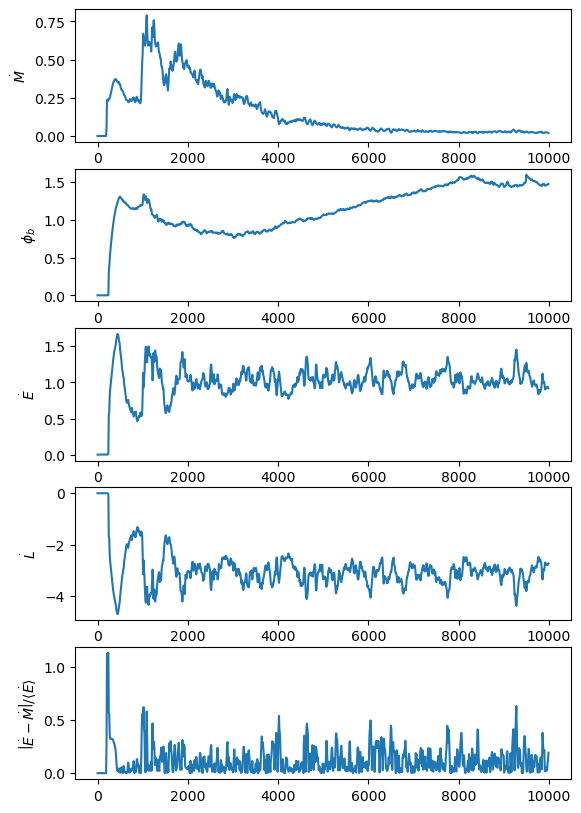

In [4]:
# r, th = ana.get_ivar('rth')
mdot = ana.get_result('t', 'mdot')
phi_b = ana.get_result('t', 'phi_b')
edot = ana.get_result('t', 'edot')
ldot = ana.get_result('t', 'ldot')
eff = ana.get_result('t', 'eff')

figs, axs = plt.subplots(5, 1, figsize=(6.4, 10))
axs[0].plot(mdot[0], mdot[1])
axs[0].set_ylabel(r'$\dot{M}$')
axs[1].plot(phi_b[0], phi_b[1])
axs[1].set_ylabel(r'$\phi_b$')
axs[2].plot(edot[0], edot[1])
axs[2].set_ylabel(r'$\dot{E}$')
axs[3].plot(ldot[0], ldot[1])
axs[3].set_ylabel(r'$\dot{L}$')
axs[4].plot(eff[0], eff[1])
axs[4].set_ylabel(r'$\left|\dot{E} - \dot{M}\right| / \langle\dot{E}\rangle$')
plt.show()



In [5]:
rav = ana.get_ivar('r')
print(rav)

[array([  1.66961066,   1.7071657 ,   1.74556548,   1.784829  ,
         1.82497569,   1.8660254 ,   1.90799846,   1.95091564,
         1.99479816,   2.03966774,   2.08554659,   2.1324574 ,
         2.1804234 ,   2.2294683 ,   2.27961639,   2.33089248,
         2.38332193,   2.43693069,   2.49174529,   2.54779286,
         2.60510111,   2.66369842,   2.72361378,   2.78487682,
         2.84751788,   2.91156794,   2.9770587 ,   3.04402256,
         3.11249266,   3.18250287,   3.25408785,   3.32728301,
         3.40212456,   3.47864956,   3.55689585,   3.63690215,
         3.71870807,   3.80235407,   3.88788154,   3.9753328 ,
         4.06475114,   4.15618079,   4.24966699,   4.345256  ,
         4.44299513,   4.54293273,   4.64511825,   4.74960227,
         4.85643647,   4.96567373,   5.0773681 ,   5.19157484,
         5.30835046,   5.42775275,   5.5498408 ,   5.674675  ,
         5.80231714,   5.93283038,   6.06627928,   6.20272989,
         6.34224972,   6.48490782,   6.63077476,   6.7

In [6]:
rav_mdot = ana.get_result('r', 'mdot')
print(rav_mdot[0].shape, rav_mdot[1].shape)
# plt.plot(rav_mdot[0], rav_mdot[1])
# plt.show()



(288,) (1000,)


In [7]:
print(ana['t'].shape)
print(ana['r'].shape)
print(ana['rth'][0].shape, ana['rth'][1].shape)
print(ana['rtht/rho'].shape)
# print(ana['t/phi_b'].shape)
# print(ana['t/mdot'].shape)
# print(ana['r/phi_b'].shape)





(1000,)
(288,)
(289, 193) (289, 193)
(1000, 288, 192)


/tmp/ipykernel_1639236/1354010147.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


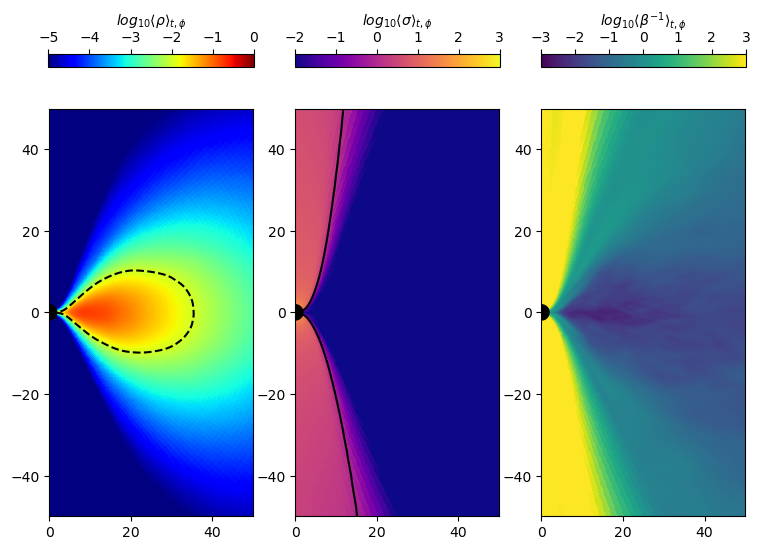

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

X = ana['rth'][0][:-1, :-1]
Y = ana['rth'][1][:-1, :-1]


r_eh = 1.8660254037844386

rav_rho = np.log10(np.mean(ana['rtht/rho'][500:1000, :, :], axis=0))
rav_sigma = np.log10(np.mean(ana['rtht/sigma'][500:1000, :, :], axis=0))
rav_inv_beta = np.log10(np.mean(ana['rtht/inv_beta'][500:1000, :, :], axis=0))

# 创建带有额外空间的图形
fig2 = plt.figure(figsize=(9, 6))
# 创建网格规范，减小colorbar的相对高度
gs = fig2.add_gridspec(2, 3, height_ratios=[0.03, 1], hspace=0.2)

# 创建三个主要的子图
ax1 = fig2.add_subplot(gs[1, 0])
ax2 = fig2.add_subplot(gs[1, 1])
ax3 = fig2.add_subplot(gs[1, 2])
axs2 = [ax1, ax2, ax3]

# 密度图
im0 = axs2[0].pcolormesh(ana['rth'][0], ana['rth'][1], rav_rho, 
                         norm=Normalize(vmin=-5, vmax=0),
                         cmap='jet')
axs2[0].fill(r_eh*np.cos(np.linspace(0, 2*np.pi, 100)), r_eh*np.sin(np.linspace(0, 2*np.pi, 100)), color='black')
# Add contour line where log10(rho) = -2 (rho = 0.01)
contour_levels_rho = [-2]
cs0 = axs2[0].contour(X, Y, rav_rho, 
                      levels=contour_levels_rho, colors='black')
# axs2[0].clabel(cs0, fmt='%2.1f', colors='black')

axs2[0].set_xlim(0, 50)
axs2[0].set_ylim(-50, 50)
axs2[0].set_aspect('equal')
cax0 = fig2.add_subplot(gs[0, 0])
cbar0 = plt.colorbar(im0, cax=cax0, orientation='horizontal')
cbar0.ax.xaxis.set_ticks_position('top')
cbar0.ax.xaxis.set_label_position('top')
cbar0.set_ticks([-5, -4, -3, -2, -1, 0])
cbar0.set_label(r'$log_{10}\langle\rho\rangle_{t,\phi}$')


# sigma图
im1 = axs2[1].pcolormesh(ana['rth'][0], ana['rth'][1], rav_sigma,
                         norm=Normalize(vmin=-2, vmax=3),
                         cmap='plasma')
axs2[1].fill(r_eh*np.cos(np.linspace(0, 2*np.pi, 100)), r_eh*np.sin(np.linspace(0, 2*np.pi, 100)), color='black')
# 增加sigma=1的等值线
contour_levels_sigma = [0]
cs1 = axs2[1].contour(X, Y, rav_sigma, 
                      levels=contour_levels_sigma, colors='black')
# axs2[1].clabel(cs1, fmt='%2.1f', colors='black')

axs2[1].set_xlim(0, 50)
axs2[1].set_ylim(-50, 50)
axs2[1].set_aspect('equal')
cax1 = fig2.add_subplot(gs[0, 1])
cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.ax.xaxis.set_ticks_position('top')
cbar1.ax.xaxis.set_label_position('top')
cbar1.set_ticks([-2, -1, 0, 1, 2, 3])
cbar1.set_label(r'$log_{10}\langle\sigma\rangle_{t,\phi}$')

# beta^-1图
im2 = axs2[2].pcolormesh(ana['rth'][0], ana['rth'][1], rav_inv_beta,
                         norm=Normalize(vmin=-3, vmax=3),
                         cmap='viridis')
axs2[2].fill(r_eh*np.cos(np.linspace(0, 2*np.pi, 100)), r_eh*np.sin(np.linspace(0, 2*np.pi, 100)), color='black')
axs2[2].set_xlim(0, 50)
axs2[2].set_ylim(-50, 50)
axs2[2].set_aspect('equal')
cax2 = fig2.add_subplot(gs[0, 2])
cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.ax.xaxis.set_ticks_position('top')
cbar2.ax.xaxis.set_label_position('top')
cbar2.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cbar2.set_label(r'$log_{10}\langle\beta^{-1}\rangle_{t,\phi}$')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1639236/3378242256.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


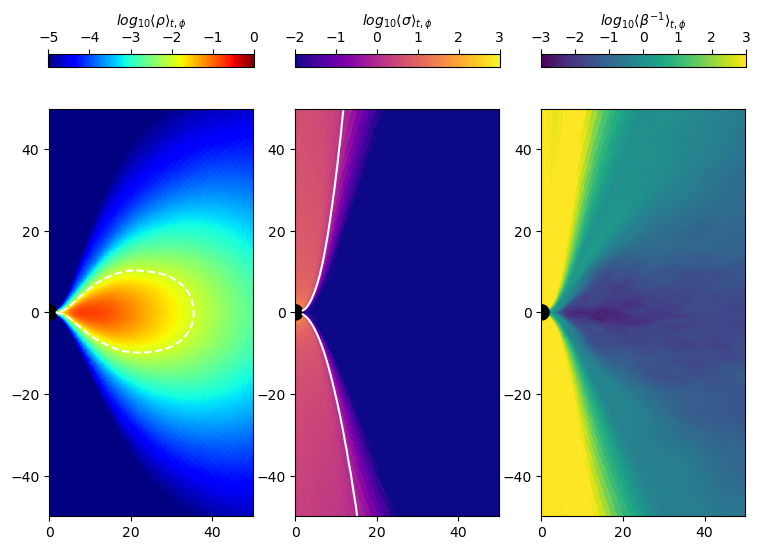

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np

# Assuming 'ana' is your data dictionary and the data has been loaded appropriately

r_eh = 1.8660254037844386

# Averaging over the time dimension
rav_rho = np.log10(np.mean(ana['rtht/rho'][500:1000, :, :], axis=0))
rav_sigma = np.log10(np.mean(ana['rtht/sigma'][500:1000, :, :], axis=0))
rav_inv_beta = np.log10(np.mean(ana['rtht/inv_beta'][500:1000, :, :], axis=0))

# Adjust the grid arrays for contour plots
X = ana['rth'][0][:-1, :-1]
Y = ana['rth'][1][:-1, :-1]

# Create the figure and gridspec
fig2 = plt.figure(figsize=(9, 6))
gs = fig2.add_gridspec(2, 3, height_ratios=[0.03, 1], hspace=0.2)

# Create the subplots
ax1 = fig2.add_subplot(gs[1, 0])
ax2 = fig2.add_subplot(gs[1, 1])
ax3 = fig2.add_subplot(gs[1, 2])
axs2 = [ax1, ax2, ax3]

# Density plot
im0 = axs2[0].pcolormesh(ana['rth'][0], ana['rth'][1], rav_rho, 
                         norm=Normalize(vmin=-5, vmax=0),
                         cmap='jet', shading='auto')
axs2[0].fill(r_eh * np.cos(np.linspace(0, 2 * np.pi, 100)), 
             r_eh * np.sin(np.linspace(0, 2 * np.pi, 100)), color='black')

# Add contour line where log10(rho) = -2 (rho = 0.01)
contour_levels_rho = [-2]
cs0 = axs2[0].contour(X, Y, rav_rho, 
                      levels=contour_levels_rho, colors='white')
# axs2[0].clabel(cs0, fmt='%2.1f', colors='white')

axs2[0].set_xlim(0, 50)
axs2[0].set_ylim(-50, 50)
axs2[0].set_aspect('equal')
cax0 = fig2.add_subplot(gs[0, 0])
cbar0 = plt.colorbar(im0, cax=cax0, orientation='horizontal')
cbar0.ax.xaxis.set_ticks_position('top')
cbar0.ax.xaxis.set_label_position('top')
cbar0.set_ticks([-5, -4, -3, -2, -1, 0])
cbar0.set_label(r'$log_{10}\langle\rho\rangle_{t,\phi}$')

# Sigma plot
im1 = axs2[1].pcolormesh(ana['rth'][0], ana['rth'][1], rav_sigma,
                         norm=Normalize(vmin=-2, vmax=3),
                         cmap='plasma', shading='auto')
axs2[1].fill(r_eh * np.cos(np.linspace(0, 2 * np.pi, 100)), 
             r_eh * np.sin(np.linspace(0, 2 * np.pi, 100)), color='black')

# Add contour line where log10(sigma) = 0 (sigma = 1)
contour_levels_sigma = [0]
cs1 = axs2[1].contour(X, Y, rav_sigma, 
                      levels=contour_levels_sigma, colors='white')
# axs2[1].clabel(cs1, fmt='%2.1f', colors='white')

axs2[1].set_xlim(0, 50)
axs2[1].set_ylim(-50, 50)
axs2[1].set_aspect('equal')
cax1 = fig2.add_subplot(gs[0, 1])
cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.ax.xaxis.set_ticks_position('top')
cbar1.ax.xaxis.set_label_position('top')
cbar1.set_ticks([-2, -1, 0, 1, 2, 3])
cbar1.set_label(r'$log_{10}\langle\sigma\rangle_{t,\phi}$')

# Beta^-1 plot
im2 = axs2[2].pcolormesh(ana['rth'][0], ana['rth'][1], rav_inv_beta,
                         norm=Normalize(vmin=-3, vmax=3),
                         cmap='viridis', shading='auto')
axs2[2].fill(r_eh * np.cos(np.linspace(0, 2 * np.pi, 100)), 
             r_eh * np.sin(np.linspace(0, 2 * np.pi, 100)), color='black')

# Optionally, add contour lines for rav_inv_beta if desired
# For example, contour where log10(beta^-1) = 0 (beta^-1 = 1)
# contour_levels_inv_beta = [0]
# cs2 = axs2[2].contour(X, Y, rav_inv_beta, 
#                       levels=contour_levels_inv_beta, colors='white')
# axs2[2].clabel(cs2, fmt='%2.1f', colors='white')

axs2[2].set_xlim(0, 50)
axs2[2].set_ylim(-50, 50)
axs2[2].set_aspect('equal')
cax2 = fig2.add_subplot(gs[0, 2])
cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.ax.xaxis.set_ticks_position('top')
cbar2.ax.xaxis.set_label_position('top')
cbar2.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cbar2.set_label(r'$log_{10}\langle\beta^{-1}\rangle_{t,\phi}$')

plt.tight_layout()
plt.show()


In [10]:
import h5py
import numpy as np

def print_group_structure(group, indent=""):
    for key in group.keys():
        print(f"{indent}{key}")
        if isinstance(group[key], h5py.Group):
            print_group_structure(group[key], indent + "  ")

def print_datasets(group, path=""):
    for key, item in group.items():
        new_path = f"{path}/{key}"
        if isinstance(item, h5py.Dataset):
            print(f"{new_path}: shape {item.shape}, dtype {item.dtype}")
        elif isinstance(item, h5py.Group):
            print_datasets(item, new_path)

def print_attributes(group, path=""):
    for key, item in group.items():
        new_path = f"{path}/{key}"
        if isinstance(item, h5py.Dataset) or isinstance(item, h5py.Group):
            if len(item.attrs) > 0:
                print(f"\n{new_path} 属性:")
                for attr_name, attr_value in item.attrs.items():
                    print(f"  {attr_name}: {attr_value}")
        if isinstance(item, h5py.Group):
            print_attributes(item, new_path)


# 在 explore_hdf5 函数中添加对 check_version 的调用
def explore_hdf5(file_path):
    with h5py.File(file_path, 'r') as f:
        print(f"文件: {file_path}")
        
        print("\n群组结构:")
        print_group_structure(f)
        
        print("\n数据集:")
        print_datasets(f)
        
        print("\n属性:")
        print_attributes(f)


In [11]:
explore_hdf5(ana_file)


文件: /home/zhangzelin/projects/kharma-data-sync/20241216_cuda_sane_a05000_288-192-128_6-12_rout1000_min020_gamma13/eht_out.h5

群组结构:
avg
  end
  start
coord
  t
diag
  Ang_Mom
  EHT_Lum_Proxy
  Edot
  Edot_5M
  Edot_5M_Flux
  Edot_EH
  Edot_EH_Flux
  Edot_Flux
  Egas
  FFlags
  Jet_Lum
  Ldot
  Ldot_0_Flux
  Ldot_5M
  Ldot_5M_Flux
  Ldot_EH
  Ldot_EH_Flux
  Mass
  MaxDivB
  Mdot
  Mdot_5M
  Mdot_5M_Flux
  Mdot_EH
  Mdot_EH_Flux
  Mdot_Flux
  PFlags
  Phi_0
  Phi_5M
  Phi_EH
  X1_Mom
  X2_Mom
  dt
  time
extras
  pyharm_params
header
  a
  base
  cfl
  connection_average_points
  coordinates
  correct_connections
  cour
  derefine_tol
  domain_intersects_eh
  dt
  dt_min
  dump_cadence
  dx1
  dx2
  dx3
  electrons
  emhd
  ext_g
  fname_fill
  gam
  gam_e
  gam_p
  gamma
  geom
    dx1
    dx2
    dx3
    mks
      a
      hslope
      r_eh
      r_in
      r_out
    n_dim
    startx1
    startx2
    startx3
  gridfile
  hslope
  ideal_guess
  implicit
  integrator
  ix1_bc
  ix2_bc
  i

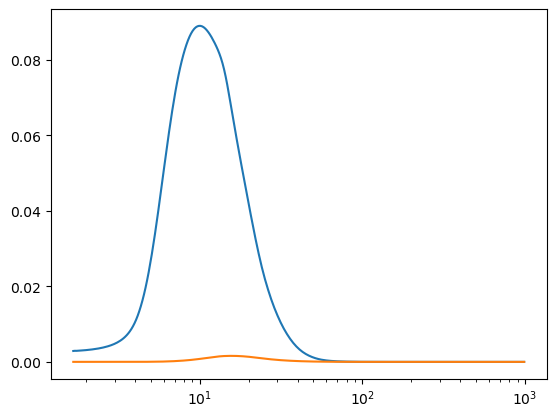

In [12]:
r_base = ana['r']
rt_rho_disk = ana['rt/rho_disk'][500:1000,:]
rt_rho_notdisk = ana['rt/rho_notdisk'][500:1000,:]
plt.plot(r_base, np.mean(rt_rho_disk, axis=0), label='disk')
plt.plot(r_base, np.mean(rt_rho_notdisk, axis=0), label='not disk')
plt.xscale('log')
plt.show()



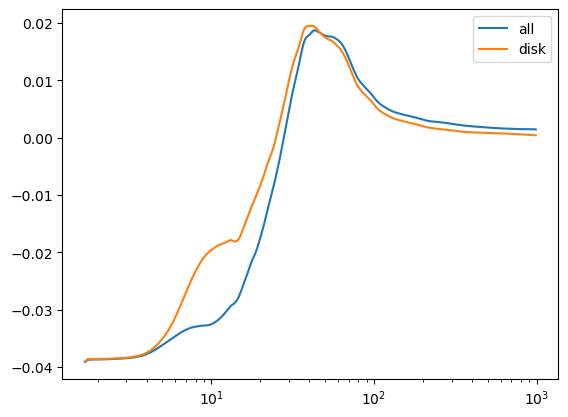

In [13]:
rt_FM_all = ana['rt/FM_all'][500:1000,:]
rt_FM_disk = ana['rt/FM_disk'][500:1000,:]

plt.plot(r_base, np.mean(rt_FM_all, axis=0), label='all')
plt.plot(r_base, np.mean(rt_FM_disk, axis=0), label='disk')
plt.legend()
plt.xscale('log')
plt.show()

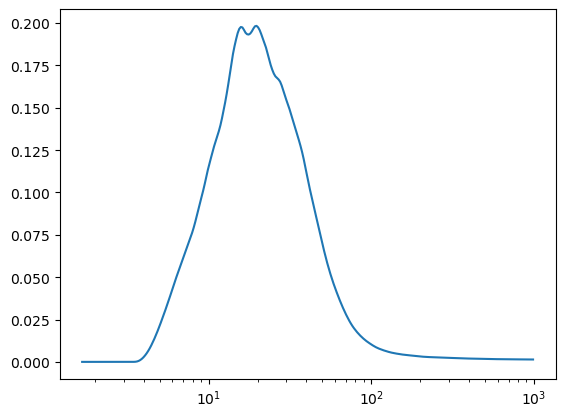

In [14]:
rt_outflow = ana['rt/outflow'][500:1000,:]
plt.plot(r_base, np.mean(rt_outflow, axis=0))
plt.xscale('log')
plt.show()